In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lorentzyeung/price-paid-data-202304/October 2025 data.csv
/kaggle/input/datasets/lorentzyeung/price-paid-data-202304/April 2025 data.csv
/kaggle/input/datasets/lorentzyeung/price-paid-data-202304/March 2024 data.csv
/kaggle/input/datasets/lorentzyeung/price-paid-data-202304/pp-complete.csv
/kaggle/input/datasets/lorentzyeung/price-paid-data-202304/September 2025 data.csv
/kaggle/input/datasets/lorentzyeung/price-paid-data-202304/August 2025 data.csv
/kaggle/input/datasets/lorentzyeung/price-paid-data-202304/January 2025 data.csv
/kaggle/input/datasets/lorentzyeung/price-paid-data-202304/December 2025 data.csv
/kaggle/input/datasets/lorentzyeung/price-paid-data-202304/May 2025 data.csv
/kaggle/input/datasets/lorentzyeung/price-paid-data-202304/June 2025 data.csv
/kaggle/input/datasets/lorentzyeung/price-paid-data-202304/January 2026 data.csv
/kaggle/input/datasets/lorentzyeung/price-paid-data-202304/December 2024 data.csv
/kaggle/input/datasets/lorentzyeung/price-

**Importing libraries and loading data**

In [2]:
# Import necessary libraries
import numpy as np  # Import NumPy for handling numerical operations
import pandas as pd  # Import Pandas for data manipulation and analysis
import warnings  # Import Warnings to suppress unnecessary warnings

# Suppress warning messages
warnings.filterwarnings("ignore")

# Import SHAP for interpreting model predictions
import shap

# Import matplotlib for data visualization
import matplotlib.pyplot as plt

# Import CatBoostRegressor for building a regression model
from catboost import Pool, CatBoostRegressor

# Import mean_squared_error for evaluating model performance
from sklearn.metrics import mean_squared_error

# Import train_test_split for splitting the data into training and testing sets
from sklearn.model_selection import train_test_split

# Import CountVectorizer from sklearn.feature_extraction.text for text feature extraction
from sklearn.feature_extraction.text import CountVectorizer

# Import ast and re for working with text and regular expressions
import ast
import re

# Import gc for garbage collection
import gc

# Set Pandas options to display a maximum of 1000 rows
pd.set_option('display.max_rows', 1000)

In [7]:
# Load the raw data
colnames=['price', 'Date_of_Transfer', 
          'postcode', 'Property_Type', 'Old/New', 
          'Duration', 'PAON', 'SAON', 
          'Street', 'Locality', 'Town/City', 
          'District', 'County', 'PPDCategory_Type',
          'Record_Status - monthly_file_only'
          ] 

data2 = pd.read_csv('/kaggle/input/datasets/lorentzyeung/price-paid-data-202304/pp-complete.csv',
                  header=None,
                 names=colnames,
                 infer_datetime_format=True,
                 parse_dates=["Date_of_Transfer"],
                 dayfirst=False
                 )

In [8]:
df = data2.copy()
df.head()

,price,Date_of_Transfer,postcode,Property_Type,Old/New,Duration,PAON,SAON,Street,Locality,Town/City,District,County,PPDCategory_Type,Record_Status - monthly_file_only
0,36995,1995-03-24,SE19 3NF,F,N,L,CROWN POINT,14,BEULAH HILL,Unnamed: 10,LONDON,CROYDON,GREATER LONDON,A,A.1
1,25000,1995-03-31,E16 1LG,F,N,L,9,NaN,POLLARD CLOSE,NaN,LONDON,NEWHAM,GREATER LONDON,A,A
2,25500,1995-05-17,EN3 6EA,F,N,L,33,NaN,BRIDLE CLOSE,NaN,ENFIELD,ENFIELD,GREATER LONDON,A,A
3,42000,1995-04-21,N13 4RS,T,N,L,87,NaN,RUSSELL ROAD,NaN,LONDON,ENFIELD,GREATER LONDON,A,A
4,43000,1995-06-30,RM10 7NU,T,N,F,45,NaN,BOSWORTH ROAD,NaN,DAGENHAM,BARKING AND DAGENHAM,GREATER LONDON,A,A


In [9]:
#Inspect data
def inspect_data(data):
    return pd.DataFrame(
        {
            "dType": data.dtypes,
            "unique_amount": data.apply(lambda x:len(x.unique()), axis=0),
            "uniques": data.apply(lambda x:x.unique(), axis=0),
            "qtd_null": data.apply(lambda x: x.isnull().sum(), axis=0),
            "pct_null": data.apply(lambda x: x.isnull().sum() * 100 / len(x))
        }
    )

inspect_data(df)

,dType,unique_amount,uniques,qtd_null,pct_null
price,int64,279172,"[36995, 25000, 25500, 42000, 43000, 6500, 3800...",0,0.000000
Date_of_Transfer,datetime64[ns],11347,"[1995-03-24 00:00:00, 1995-03-31 00:00:00, 199...",0,0.000000
postcode,object,1331572,"[SE19 3NF, E16 1LG, EN3 6EA, N13 4RS, RM10 7NU...",49659,0.160167
Property_Type,object,5,"[F, T, S, D, O]",0,0.000000
Old/New,object,2,"[N, Y]",0,0.000000
Duration,object,3,"[L, F, U]",0,0.000000
PAON,object,584312,"[CROWN POINT, 9, 33, 87, 45, 10, 54, 32, 25, 1...",4184,0.013495
SAON,object,70269,"[14, nan, THE GROUND FLOOR FLAT AT, FLAT 2, FL...",27298414,88.046517
Street,object,336203,"[BEULAH HILL, POLLARD CLOSE, BRIDLE CLOSE, RUS...",493169,1.590635
Locality,object,24039,"[Unnamed: 10, nan, PERIVALE, HARLINGTON, BROCK...",11770026,37.962271


In [10]:
feat_cols = df.columns
feat_cols

Index(['price', 'Date_of_Transfer', 'postcode', 'Property_Type', 'Old/New',
       'Duration', 'PAON', 'SAON', 'Street', 'Locality', 'Town/City',
       'District', 'County', 'PPDCategory_Type',
       'Record_Status - monthly_file_only'],
      dtype='object')

In [11]:
# 1. Ensure the column is actually a datetime object
df['date'] = pd.to_datetime(df['Date_of_Transfer'])

# 2. Extract Year
df['year'] = df['date'].dt.year

# 3. Extract Month (as an integer: 1-12)
df['month'] = df['date'].dt.month

# 4. Optional: Extract Month Name (great for charts!)
df['month_name'] = df['date'].dt.month_name()

print(df.head())

   price Date_of_Transfer  postcode Property_Type Old/New Duration  \
0  36995       1995-03-24  SE19 3NF             F       N        L   
1  25000       1995-03-31   E16 1LG             F       N        L   
2  25500       1995-05-17   EN3 6EA             F       N        L   
3  42000       1995-04-21   N13 4RS             T       N        L   
4  43000       1995-06-30  RM10 7NU             T       N        F   

          PAON SAON         Street     Locality Town/City  \
0  CROWN POINT   14    BEULAH HILL  Unnamed: 10    LONDON   
1            9  NaN  POLLARD CLOSE          NaN    LONDON   
2           33  NaN   BRIDLE CLOSE          NaN   ENFIELD   
3           87  NaN   RUSSELL ROAD          NaN    LONDON   
4           45  NaN  BOSWORTH ROAD          NaN  DAGENHAM   

               District          County PPDCategory_Type  \
0               CROYDON  GREATER LONDON                A   
1                NEWHAM  GREATER LONDON                A   
2               ENFIELD  GREATER

**Trend Analysis**

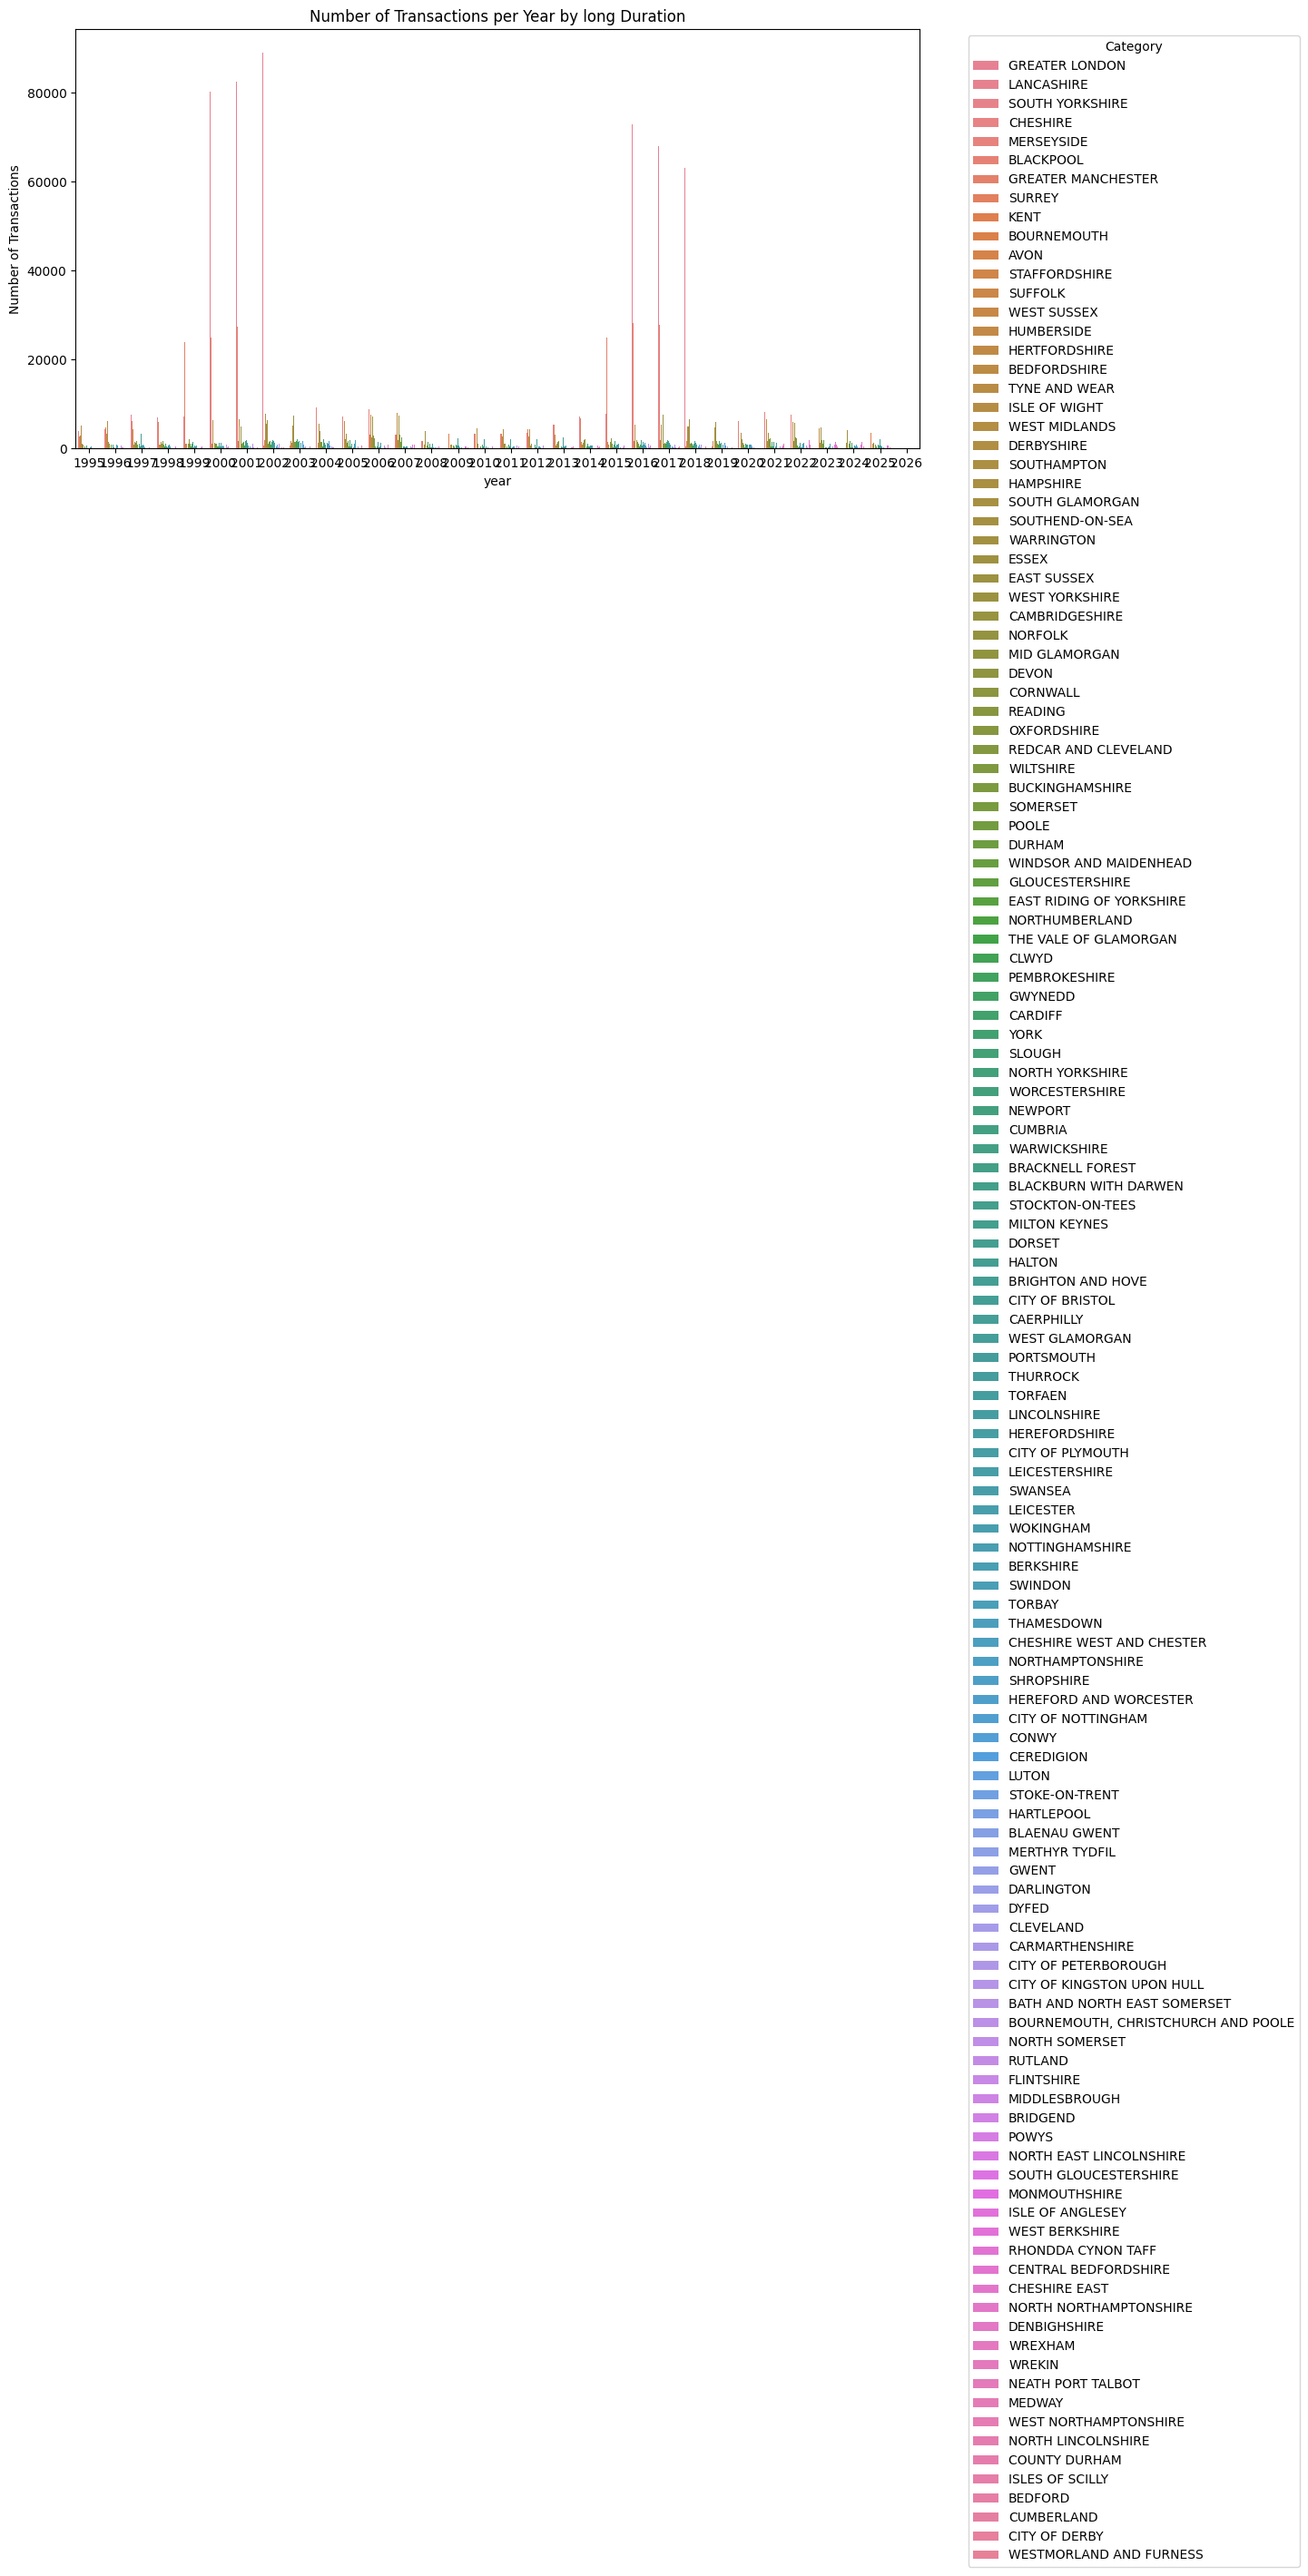

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for successful long duration transactions only
df_success = df[df['Duration'] == 'L']

plt.figure(figsize=(12, 6))
sns.countplot(data=df_success, x='year', hue='County')

plt.title('Number of Transactions per Year by long Duration')
plt.ylabel('Number of Transactions')
plt.xlabel('year')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()